In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.compose import ColumnTransformer

import json

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DIR_FOR_FIGURES = './artifacts/figures/'
DIR_FOR_ARTIFACTS = './artifacts/'
DIRS_FOR_DATASETS = [DIR_FOR_FIGURES + i for i in ['dataset-01', 'dataset-02', 'dataset-04']]

best_configs = {
    'dataset-01': {},
    'dataset-02': {},
    'dataset-04': {},
}
metrics_summary = {
    'dataset-01': {},
    'dataset-02': {},
    'dataset-04': {},
}

In [3]:
def save_csv_labels(path, label, cluster):
    cluster = pd.Series(cluster)
    cluster = cluster.where(cluster == -1, cluster + 1)
    df = pd.DataFrame({
        'sample_id': label,
        'cluster_label': cluster.astype(int)
    })

    df.to_csv(path, index=False)

def save_json(path, data):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

In [4]:
df1 = pd.read_csv('./data/S07-hw-dataset-01.csv')
df2 = pd.read_csv('./data/S07-hw-dataset-02.csv')
df3 = pd.read_csv('./data/S07-hw-dataset-04.csv')

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [6]:
print(df1.shape)
df1.describe()

(12000, 9)


,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [7]:
df1.head(n=5)

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [8]:
df1.isna().sum()

sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64

В датасете №1 все признаки числовые, так как имеют тип float64

In [9]:
X1 = df1.drop(columns=['sample_id'])
sample_id_1 = df1.sample_id

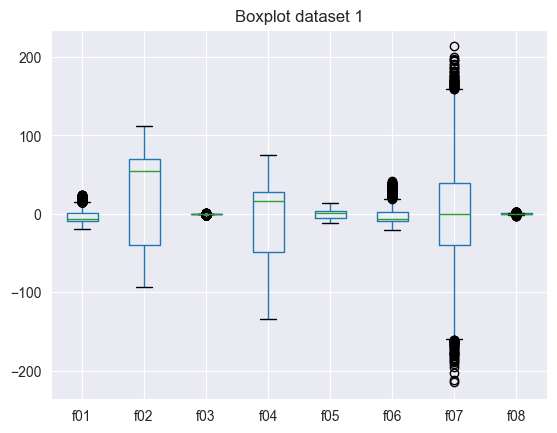

In [10]:
X1.boxplot()
plt.title("Boxplot dataset 1")
plt.savefig(f'{DIRS_FOR_DATASETS[0]}/boxplot.png')
plt.show()

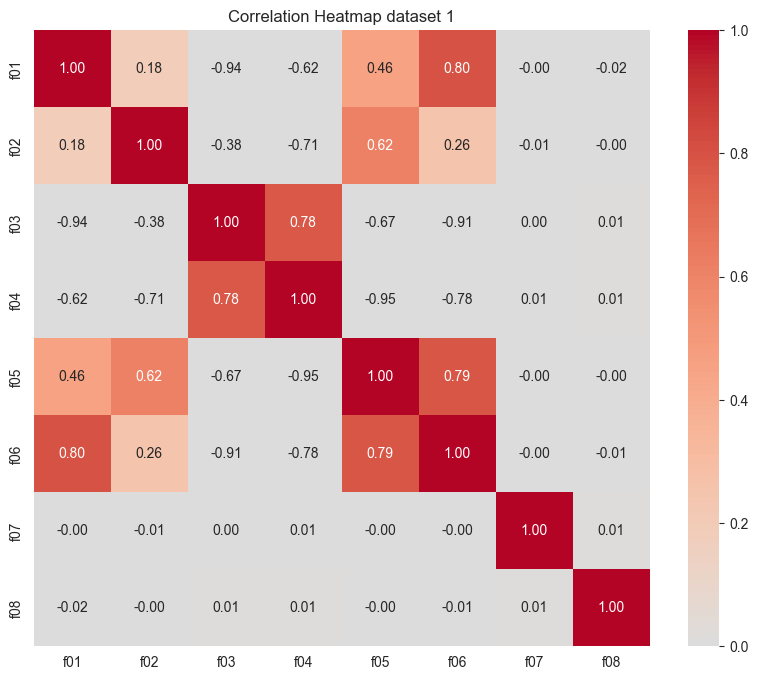

In [11]:
corr1 = X1.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr1, 
    cmap='coolwarm',
    vmin=0, 
    vmax=1, 
    center=0,
    square=True, 
    annot=True, 
    fmt='.2f')
plt.title("Correlation Heatmap dataset 1")
plt.savefig(f'{DIRS_FOR_DATASETS[0]}/corr.png')
plt.show()

In [12]:
X1 = df1.drop(columns=['f07', 'f08'])

In [13]:
pipeline1 = Pipeline(
    [
        ("scaler", StandardScaler()),
    ]
)
X1_prepared = pipeline1.fit_transform(X1)

In [14]:
k_vals = range(2, 21)
silhouette_scores = []

for k in k_vals:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    labels = kmeans.fit_predict(X1_prepared)
    silhouette_scores.append(silhouette_score(X1_prepared, labels))

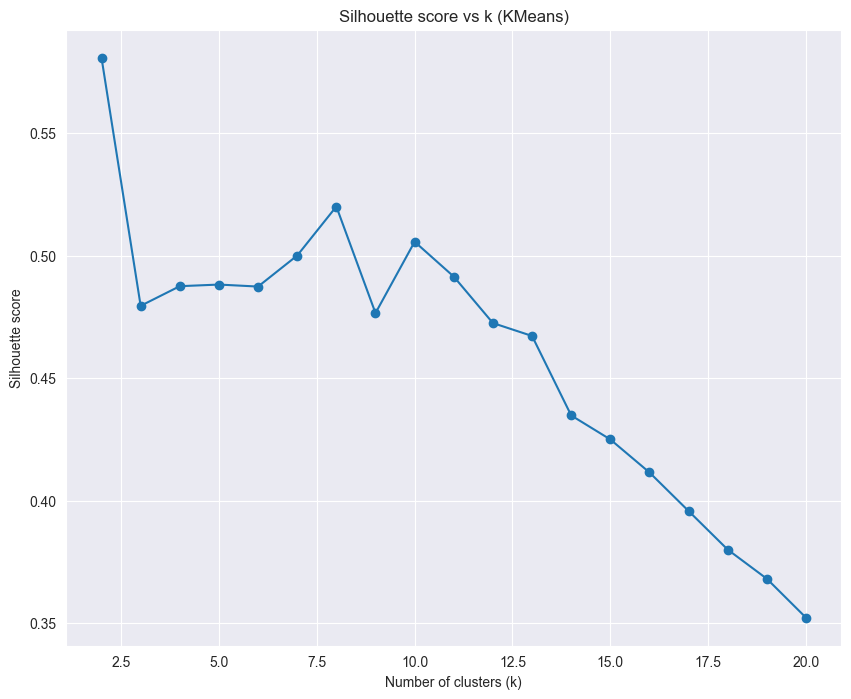

In [15]:
plt.figure(figsize=(10, 8))
plt.plot(k_vals, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score vs k (KMeans)')
plt.grid(True)
plt.savefig(f'{DIRS_FOR_DATASETS[0]}/silhouette_score_vs_k.png')
plt.show()
plt.close()

In [16]:
best_k = k_vals[np.argmax(silhouette_scores)]
best_k

2

In [17]:
final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE,
)

labels = final_kmeans.fit_predict(X1_prepared)

silhouette = silhouette_score(X1_prepared, labels)
davies_bouldin = davies_bouldin_score(X1_prepared, labels)
calinski_harabasz = calinski_harabasz_score(X1_prepared, labels)

metrics_summary['dataset-01'] = {'KMean': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz}}

print(f"Silhouette: {silhouette:.3f}")
print(f"Davies-Bouldin: {davies_bouldin:.3f}")
print(f"Calinski-Harabasz: {calinski_harabasz:.1f}")

Silhouette: 0.581
Davies-Bouldin: 0.569
Calinski-Harabasz: 15669.6


In [18]:
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels_db = dbscan.fit_predict(X1_prepared)
        
        noise_share = np.mean(labels_db == -1)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        
        mask = labels_db != -1
        
        if n_clusters >= 2 and mask.sum()>1:
            silhouette = silhouette_score(X1_prepared[mask], labels_db[mask])
            davies_bouldin = davies_bouldin_score(X1_prepared[mask], labels_db[mask])
            calinski_harabasz = calinski_harabasz_score(X1_prepared[mask], labels_db[mask])
        else:
            silhouette, davies_bouldin, calinski_harabasz = np.nan, np.nan, np.nan
        
        results.append((eps, ms, n_clusters, silhouette, davies_bouldin, calinski_harabasz))

In [19]:
res_df = pd.DataFrame(
    results,
    columns=['eps', 'ms', 'n_clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz']
)
res_df.sort_values('silhouette', ascending=False).head(10)

,eps,ms,n_clusters,silhouette,davies_bouldin,calinski_harabasz
2,0.1,10,6,0.644027,0.470216,1622.977644
65,2.2,10,2,0.580861,0.568829,15669.614326
66,2.3,3,2,0.580861,0.568829,15669.614326
67,2.3,5,2,0.580861,0.568829,15669.614326
68,2.3,10,2,0.580861,0.568829,15669.614326
69,2.4,3,2,0.580861,0.568829,15669.614326
70,2.4,5,2,0.580861,0.568829,15669.614326
71,2.4,10,2,0.580861,0.568829,15669.614326
72,2.5,3,2,0.580861,0.568829,15669.614326
73,2.5,5,2,0.580861,0.568829,15669.614326


In [84]:
final_dbscan = DBSCAN(
    eps=2.2,
    min_samples=10
)

labels = final_kmeans.fit_predict(X1_prepared)

silhouette = silhouette_score(X1_prepared, labels)
davies_bouldin = davies_bouldin_score(X1_prepared, labels)
calinski_harabasz = calinski_harabasz_score(X1_prepared, labels)

metrics_summary['dataset-01'].update({'DBScan': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz, "noise_share": np.mean(labels == -1)}})

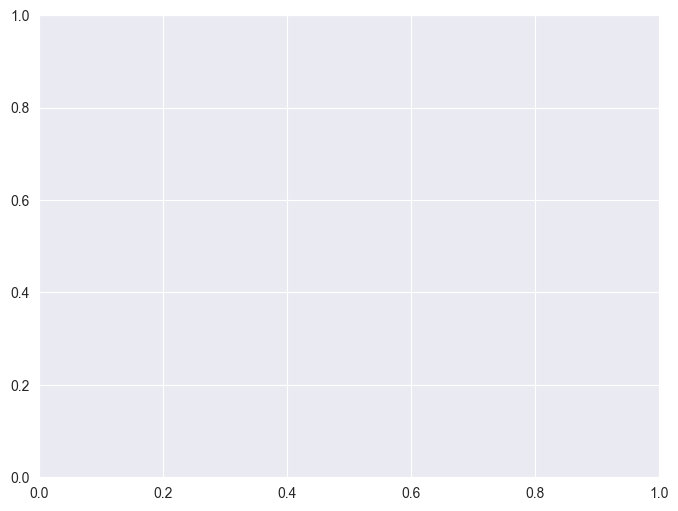

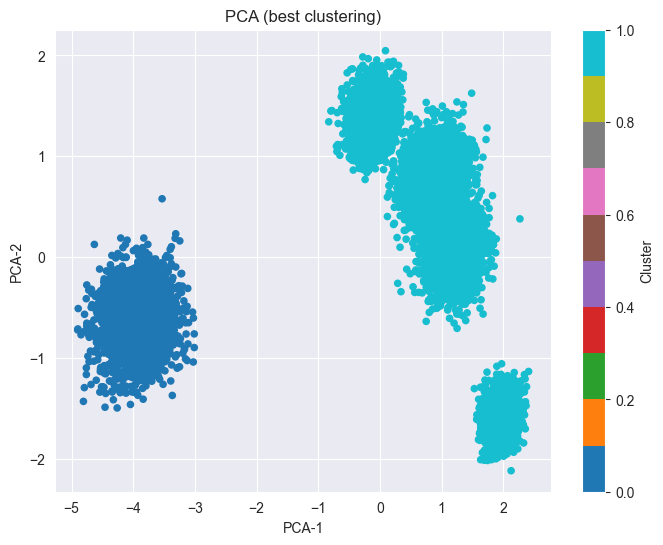

In [85]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X1_prepared)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    s=20
)
plt.xlabel('PCA-1')
plt.ylabel('PCA-2')
plt.title('PCA (best clustering)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.savefig(f'{DIRS_FOR_DATASETS[0]}/pca.png')
plt.show()
plt.close()

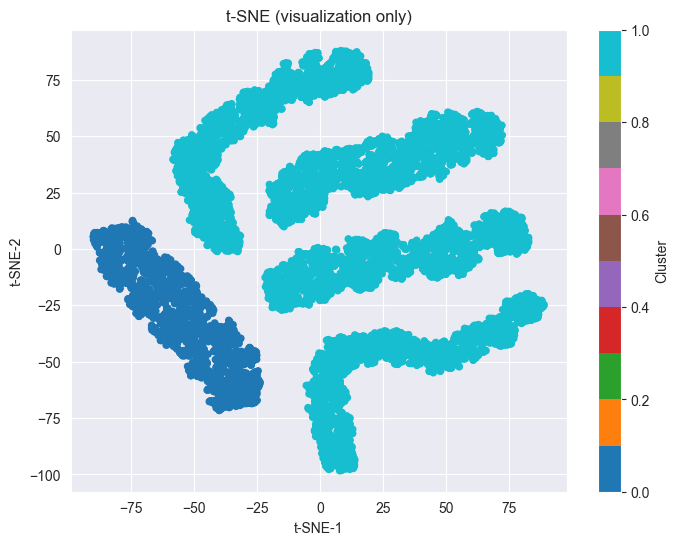

In [86]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne = tsne.fit_transform(X1_prepared)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    cmap='tab10',
    s=20
)
plt.xlabel('t-SNE-1')
plt.ylabel('t-SNE-2')
plt.title('t-SNE (visualization only)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.savefig(f'{DIRS_FOR_DATASETS[0]}/t-sne.png')
plt.show()
plt.close()

In [28]:
labels_runs = []

for rs in [1, 42, 420, 777, 999]:
    km = KMeans(
        n_clusters=best_k,
        random_state=rs,
        n_init=10,
    )
    labels_runs.append(km.fit_predict(X1_prepared))
    
aris = []
for i in range(1, len(labels_runs)):
    ari = adjusted_rand_score(labels_runs[0], labels_runs[i])
    aris.append(ari)
    

print("ARI scores:", aris)
print("Mean ARI:", np.mean(aris))

ARI scores: [1.0, 1.0, 1.0, 1.0]
Mean ARI: 1.0


Для оценки устойчивости мы запустили 5 раз алгоритм KMeans с разными значениями random_state: `[1, 42, 420, 777, 999]` и используя Adjusted Rand Index (ARI) мы получили значение 1.0, что свидетельствует об идентичном разбиение, которое означает, что у нас высокая степень устойчивости кластеризации

In [29]:
save_csv_labels(DIR_FOR_ARTIFACTS + "labels_ hw07_ds1.csv", sample_id_1, labels)
best_configs['dataset-01'] = {'n_clusters': best_k}

Для dataset-01 все признаки являются числовыми, пропуски отсутствуют, поэтому в качестве препроцессинга использовалось масштабирование StandardScaler.
Для кластеризации были рассмотрены алгоритмы KMeans и DBSCAN.
Для KMeans оптимальное число кластеров подбиралось в диапазоне k=2…20 по метрике silhouette score, максимум которой достигался при k=2.
Алгоритм DBSCAN показал наличие локальных плотных подструктур, однако чувствительность к параметрам eps и min_samples, а также наличие шума усложняли интерпретацию результата.
В качестве основного метода был выбран KMeans с k=2, так как он обеспечивает наилучшее соотношение компактности и разделённости кластеров по всем использованным метрикам (silhouette, Davies–Bouldin, Calinski–Harabasz).
PCA-проекция подтверждает наличие двух крупных кластеров, несмотря на визуальное появление подгрупп, что объясняется искажениями при снижении размерности.
Проверка устойчивости KMeans с разными значениями random_state показала идентичные разбиения (ARI = 1.0), что свидетельствует о высокой устойчивости кластеризации.
Таким образом, KMeans является уместным и надёжным выбором для данного датасета.

In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [31]:
df2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [32]:
df2.head(n=5)

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [33]:
df2.shape

(8000, 4)

In [34]:
df2.isna().sum()

sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64

In [35]:
X2 = df2.drop(columns=['sample_id'])
sample_id_2 = df2.sample_id

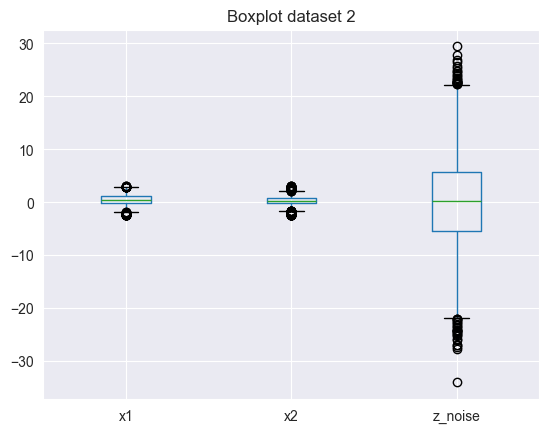

In [36]:
X2.boxplot()
plt.title("Boxplot dataset 2")
plt.savefig(f'{DIRS_FOR_DATASETS[1]}/boxplot.png')
plt.show()
plt.close()

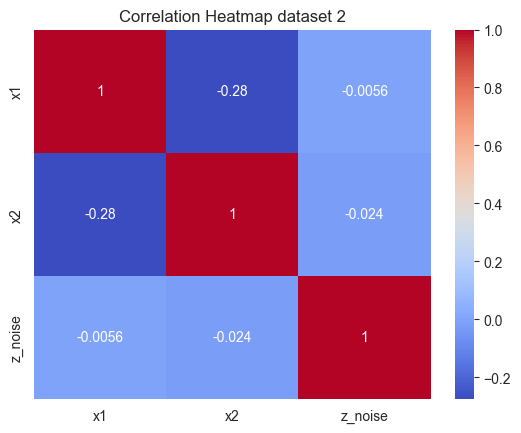

In [37]:
corr = X2.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.savefig(f'{DIRS_FOR_DATASETS[1]}/corr.png')
plt.title("Correlation Heatmap dataset 2")
plt.show()
plt.close()

## Краткий анализ данных

В нашем датасете находится столбцы x1, x2 и z_noise (помимо sample_id):
- В каждом признаки есть определённое кол-во объектов с выбросами
- Пропусков нет
- Категориальных признаков нет, поэтому OneHotEncoder нам не нужен
- Сильной корреляции между признаками не наблюдается

Исходя из выше сказанного будем использовать только `StandardScaler`

In [38]:
pipeline = Pipeline(
    [
        ('scaler', StandardScaler())
    ]
)

X2_prepared = pipeline.fit_transform(X2)

In [39]:
results = []

for k in k_vals:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )
    
    labels = km.fit_predict(X2_prepared)
    results.append((k, silhouette_score(X2_prepared, labels), davies_bouldin_score(X2_prepared, labels), calinski_harabasz_score(X2_prepared, labels)))

In [40]:
results = pd.DataFrame(results, columns=['clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz'])
results.sort_values('silhouette', ascending=False)

,clusters,silhouette,davies_bouldin,calinski_harabasz
0,2,0.306861,1.323472,3573.393333
14,16,0.283854,0.955566,2329.437184
15,17,0.282713,0.960999,2310.607765
18,20,0.281387,0.935493,2268.515211
16,18,0.279311,0.959661,2275.383717
17,19,0.278920,0.967940,2267.876459
13,15,0.276016,0.966438,2300.267547
12,14,0.271864,0.992412,2305.302085
1,3,0.270045,1.222659,3082.272075
9,11,0.265944,1.025115,2361.200917


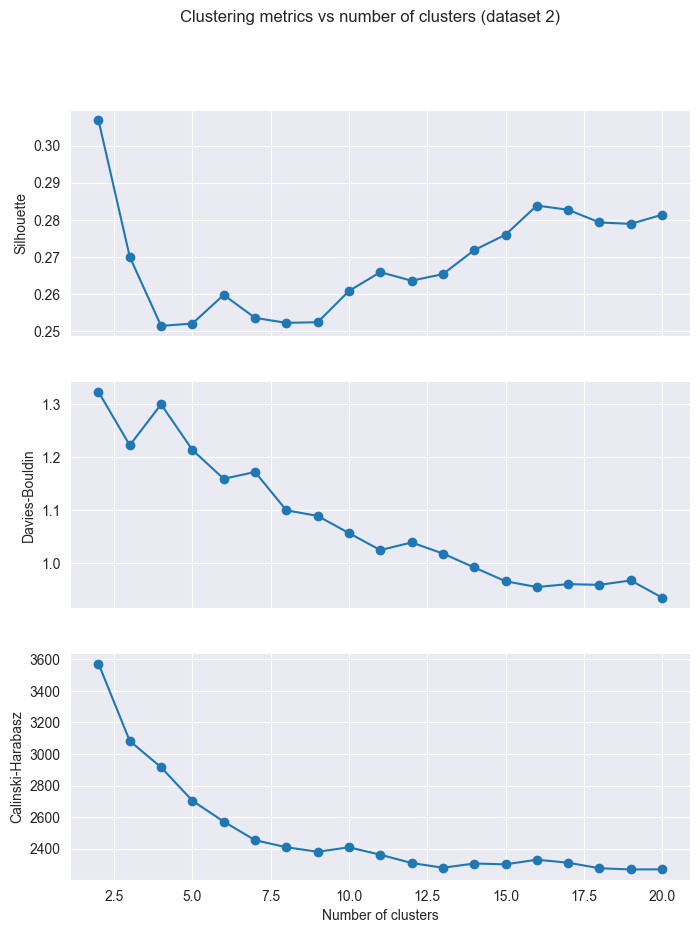

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axes[0].plot(k_vals, results['silhouette'], marker='o')
axes[0].set_ylabel('Silhouette')
axes[0].grid(True)

axes[1].plot(k_vals, results['davies_bouldin'], marker='o')
axes[1].set_ylabel('Davies-Bouldin')
axes[1].grid(True)

axes[2].plot(k_vals, results['calinski_harabasz'], marker='o')
axes[2].set_ylabel('Calinski-Harabasz')
axes[2].set_xlabel('Number of clusters')
axes[2].grid(True)

fig.suptitle('Clustering metrics vs number of clusters (dataset 2)')
plt.savefig(DIRS_FOR_DATASETS[1] + '/metrics_vs_k.png')
plt.show()
plt.close()


In [42]:
best_k = k_vals[np.argmax(results['silhouette'])]
best_k

2

In [43]:
final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=RANDOM_STATE,
)

labels = final_kmeans.fit_predict(X2_prepared)

silhouette = silhouette_score(X2_prepared, labels)
davies_bouldin = davies_bouldin_score(X2_prepared, labels)
calinski_harabasz = calinski_harabasz_score(X2_prepared, labels)

metrics_summary['dataset-02'].update({'KMeans': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz}})

In [44]:
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(
            eps=eps,
            min_samples=ms,
        )
        
        labels_db = dbscan.fit_predict(X2_prepared)
        
        mask = labels_db != -1
        noise_share = np.mean(labels_db == -1)
        
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        if n_clusters >= 2 and mask.sum() > 1:
            sil = silhouette_score(X2_prepared[mask], labels_db[mask])
            db = davies_bouldin_score(X2_prepared[mask], labels_db[mask])
            ch = calinski_harabasz_score(X2_prepared[mask], labels_db[mask]) 
        else:
            sil = np.nan
            db = np.nan
            ch = np.nan 
        results.append((eps, ms, n_clusters, sil, db, ch))

In [45]:
res_df = pd.DataFrame(
    results,
    columns=['eps', 'ms', 'n_clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz']
)
res_df.sort_values('silhouette', ascending=False).head(10)

,eps,ms,n_clusters,silhouette,davies_bouldin,calinski_harabasz
2,0.1,10,46,0.581246,0.577982,2758.122520
23,0.8,10,2,0.413828,0.599695,48.119046
18,0.7,3,2,0.345550,0.550987,10.405775
20,0.7,10,5,0.304952,0.600677,114.428692
14,0.5,10,2,0.251202,0.742073,26.168576
17,0.6,10,4,0.247896,0.660756,70.877078
16,0.6,5,12,0.138189,0.901970,69.331686
10,0.4,5,8,0.134863,0.604157,31.396115
15,0.6,3,10,0.103538,0.698515,55.516935
5,0.2,10,5,0.101366,0.955093,768.579101


In [46]:
dbscan = DBSCAN(
    eps = 0.8,
    min_samples=10
)
labels_db = dbscan.fit_predict(X2_prepared)

silhouette = silhouette_score(X2_prepared, labels)
davies_bouldin = davies_bouldin_score(X2_prepared, labels)
calinski_harabasz = calinski_harabasz_score(X2_prepared, labels)

metrics_summary['dataset-02'].update({'DBScan': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz, "noise_share": np.mean(labels_db == -1)}})

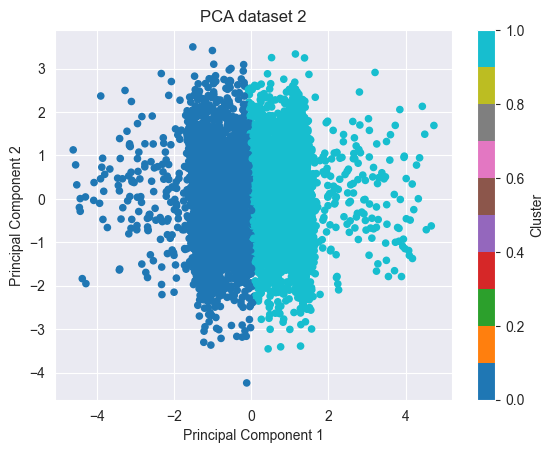

In [47]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2_pca = pca.fit_transform(X2_prepared)

plt.scatter(
    X2_pca[:, 0],
    X2_pca[:, 1],
    c=labels,
    s=20,
    cmap='tab10'
)

plt.colorbar(label='Cluster')
plt.grid(True)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA dataset 2')
plt.savefig(DIRS_FOR_DATASETS[1] + '/pca.png')
plt.show()
plt.close()

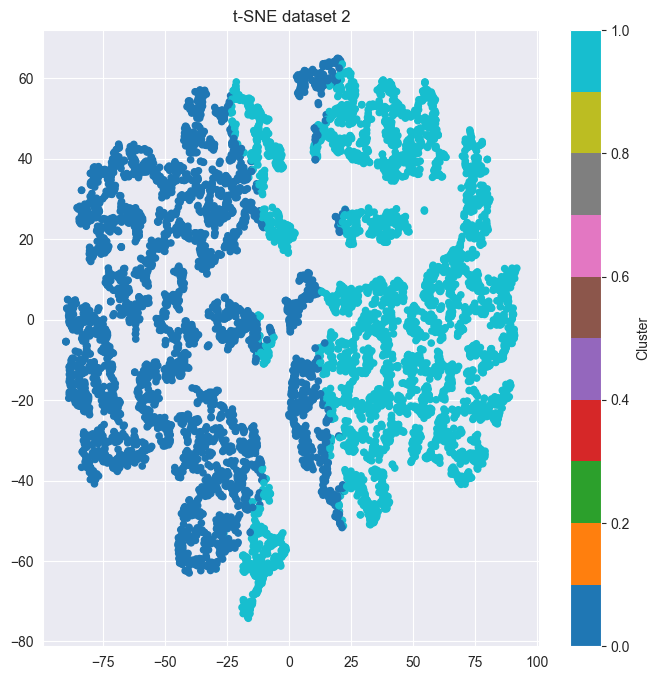

In [48]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X2_tsne = tsne.fit_transform(X2_prepared)

plt.figure(figsize=(8, 8))
plt.scatter(
    X2_tsne[:, 0],
    X2_tsne[:, 1],
    c=labels,
    s=20,
    cmap='tab10'
)
plt.colorbar(label='Cluster')
plt.grid(True)
plt.title('t-SNE dataset 2')
plt.savefig(DIRS_FOR_DATASETS[1] + '/t-sne.png')
plt.show()
plt.close()

t-SNE даёт нам не доказательство качества, а представление о локальных отображениях внутри кластеров, как можем заметить внутри 2 главных кластеров выделяются ещё несколько более мелких подгрупп, которые никак не влияют на разделение

In [81]:
save_csv_labels(DIR_FOR_ARTIFACTS + "labels_ hw07_ds2.csv", sample_id_2, labels)
best_configs['dataset-02'] = {'n_clusters': 2}

Dataset-02 представлен набором числовых признаков x1, x2 и z_noise. Пропущенные значения в данных отсутствуют, все признаки имеют тип float64 (за исключением sample_id). В датасете присутствуют выбросы, что потенциально может влиять на алгоритмы, чувствительные к масштабу и плотности данных.

Для кластеризации были рассмотрены алгоритмы KMeans и DBSCAN.

KMeans:
Для KMeans число кластеров подбиралось в диапазоне k = 2…20. Наилучшее значение метрик качества (silhouette score, Davies–Bouldin и Calinski–Harabasz) было получено при k = 2, что указывает на наличие двух глобальных кластеров в данных.

DBScan:
Для DBScan параметры eps и min_samples подбирались перебором по сетке: eps ∈ [0.1; 3.0] с шагом 0.1 и min_samples ∈ {3, 5, 10}. Оптимальная конфигурация была получена при eps = 0.8 и min_samples = 10, где значение silhouette score оказалось выше, чем у KMeans.

Итоговый вывод:
В качестве итоговой модели для данного датасета был выбран KMeans, так как он продемонстрировал лучшее разделение и более равномерное, чем DBScan и оказался более устойчивым к наличию выбросов. PCA-проекция показывает, что основное разделение объектов происходит по первой главной компоненте, которая вносит наибольший вклад в вариативность данных.

In [50]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  10000 non-null  int64  
 1   cat_b      10000 non-null  object 
 2   cat_a      10000 non-null  object 
 3   n01        9826 non-null   float64
 4   n02        9811 non-null   float64
 5   n03        9801 non-null   float64
 6   n04        9808 non-null   float64
 7   n05        9799 non-null   float64
 8   n06        9817 non-null   float64
 9   n07        9796 non-null   float64
 10  n08        9806 non-null   float64
 11  n09        9805 non-null   float64
 12  n10        9811 non-null   float64
 13  n11        9796 non-null   float64
 14  n12        9798 non-null   float64
 15  n13        9803 non-null   float64
 16  n14        9802 non-null   float64
 17  n15        9814 non-null   float64
 18  n16        9809 non-null   float64
 19  n17        9788 non-null   float64
 20  n18    

In [51]:
df3.shape

(10000, 33)

In [52]:
df3.describe()

,sample_id,n01,n02,n03,n04,n05,n06,n07,n08,n09,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
count,10000.00000,9826.000000,9811.000000,9801.000000,9808.000000,9799.000000,9817.000000,9796.000000,9806.000000,9805.000000,...,9785.000000,9804.000000,9829.000000,9793.000000,9815.000000,9776.000000,9803.000000,9789.000000,9798.000000,9805.000000
mean,4999.50000,17.348435,-2.057620,7.908302,14.269157,0.900590,5.832787,-0.840875,-4.888128,3.184200,...,-12.716502,-0.506241,8.360226,0.026943,0.039297,-0.037155,0.028512,-0.030738,-0.018685,-0.030254
std,2886.89568,22.578551,19.043410,25.637807,18.815319,20.981294,13.221646,26.583849,15.466271,32.208740,...,37.290305,14.336833,17.754646,26.121335,3.009995,3.020813,3.028106,3.000090,3.014209,3.014573
min,0.00000,-22.437090,-37.546998,-38.136412,-23.374316,-45.914070,-20.650038,-60.297304,-44.464550,-70.904880,...,-89.640783,-35.102360,-25.014050,-49.423300,-11.225848,-14.446922,-10.840777,-11.679259,-11.437909,-11.491223
25%,2499.75000,-3.975438,-14.200552,-8.591513,-1.223379,-5.086756,-4.532057,-13.554720,-17.352641,-11.460490,...,-41.284671,-11.563652,-2.123576,-19.425213,-1.973213,-2.082235,-2.007628,-2.074500,-2.051778,-2.074396
50%,4999.50000,22.042807,-6.532183,0.350400,10.069142,2.413111,7.391953,-2.429024,-7.095546,13.258691,...,-1.145681,2.491416,6.691365,-8.464171,0.037806,-0.033336,0.031588,-0.043127,-0.015441,-0.015903
75%,7499.25000,37.535647,2.092197,30.725630,29.807101,18.398883,13.033076,16.095731,3.909111,20.188426,...,18.916379,11.903004,14.939690,16.861978,2.048648,2.019027,2.056870,1.980217,2.013964,2.031215
max,9999.00000,65.446912,43.326647,60.185729,65.094588,42.527554,39.933274,48.591236,31.335431,64.696045,...,49.157087,22.452135,46.892903,61.540902,11.002135,11.394631,11.936846,10.663960,10.665988,13.755203


In [53]:
df3.head(n=5)

,sample_id,cat_b,cat_a,n01,n02,n03,n04,n05,n06,n07,...,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30
0,0,X,B,-4.827501,-24.507466,-7.852963,0.771781,28.297884,-4.493911,-42.769449,...,24.597176,-26.354320,4.543397,-19.549036,-3.051332,-5.538587,-3.084457,5.499629,-6.128896,3.132067
1,1,V,F,51.302500,NaN,5.534737,51.305464,-8.027553,28.297548,NaN,...,-18.216260,8.527932,17.202115,-30.452260,0.855326,1.199066,3.597555,-2.239703,2.932710,0.473145
2,2,W,A,-4.820828,-2.625385,27.891578,1.523041,-5.776687,-16.298523,2.462937,...,-48.260775,9.313232,12.323411,55.081325,-3.945606,-0.280540,-0.130583,-7.353205,-2.942836,1.460477
3,3,X,B,-2.627573,-25.063639,-9.450011,-8.344669,22.371118,-11.525848,-43.762607,...,24.700663,-25.466915,-3.398665,-18.174541,0.438229,3.152556,3.859283,-2.678769,-2.213923,-4.724639
4,4,Y,C,-11.415710,-8.692169,48.636163,14.661826,-39.634618,10.769075,40.187536,...,-79.710383,-13.694253,41.575892,-9.498640,1.529608,-1.641347,3.500090,3.111257,1.475232,-1.321676


In [54]:
df3.isna().sum()

sample_id      0
cat_b          0
cat_a          0
n01          174
n02          189
n03          199
n04          192
n05          201
n06          183
n07          204
n08          194
n09          195
n10          189
n11          204
n12          202
n13          197
n14          198
n15          186
n16          191
n17          212
n18          212
n19          187
n20          203
n21          215
n22          196
n23          171
n24          207
n25          185
n26          224
n27          197
n28          211
n29          202
n30          195
dtype: int64

In [55]:
X3 = df3.drop(columns=['sample_id'])
sample_id_3 = df3['sample_id']

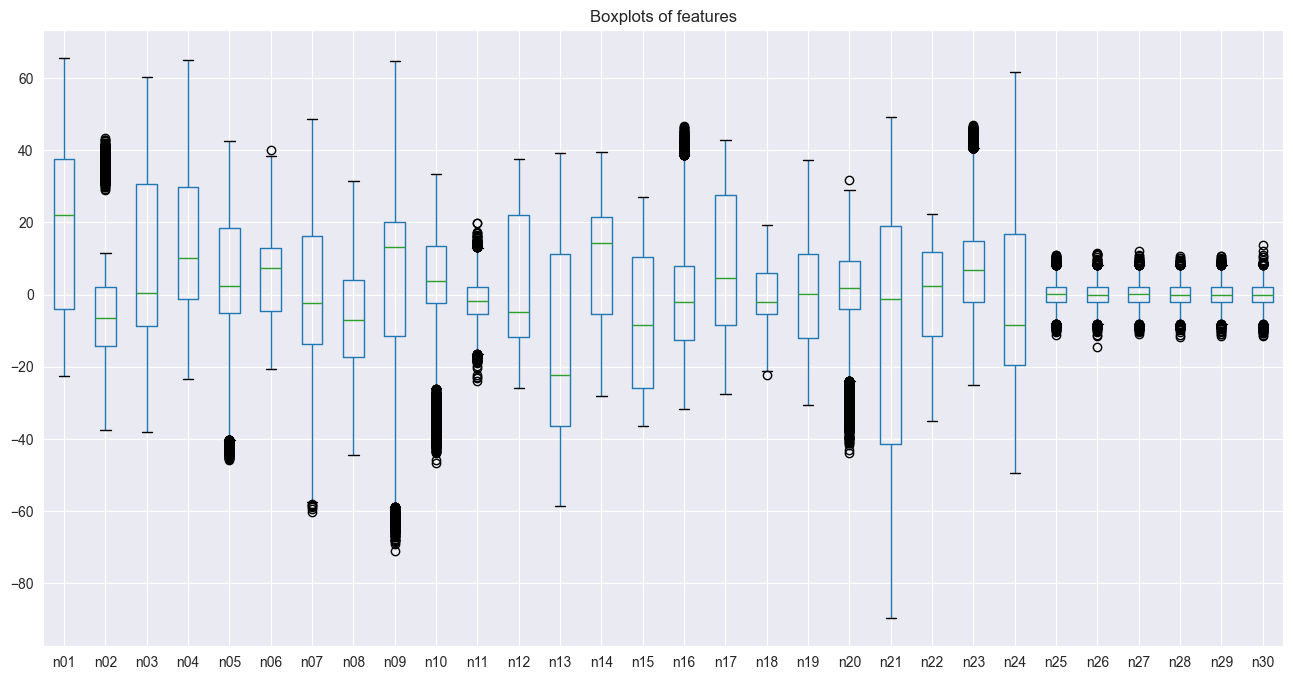

In [56]:
plt.figure(figsize=(16, 8))
X3.boxplot()
plt.title('Boxplots of features')
plt.show()
plt.savefig(DIRS_FOR_DATASETS[2] + "/boxplot.png")
plt.close()

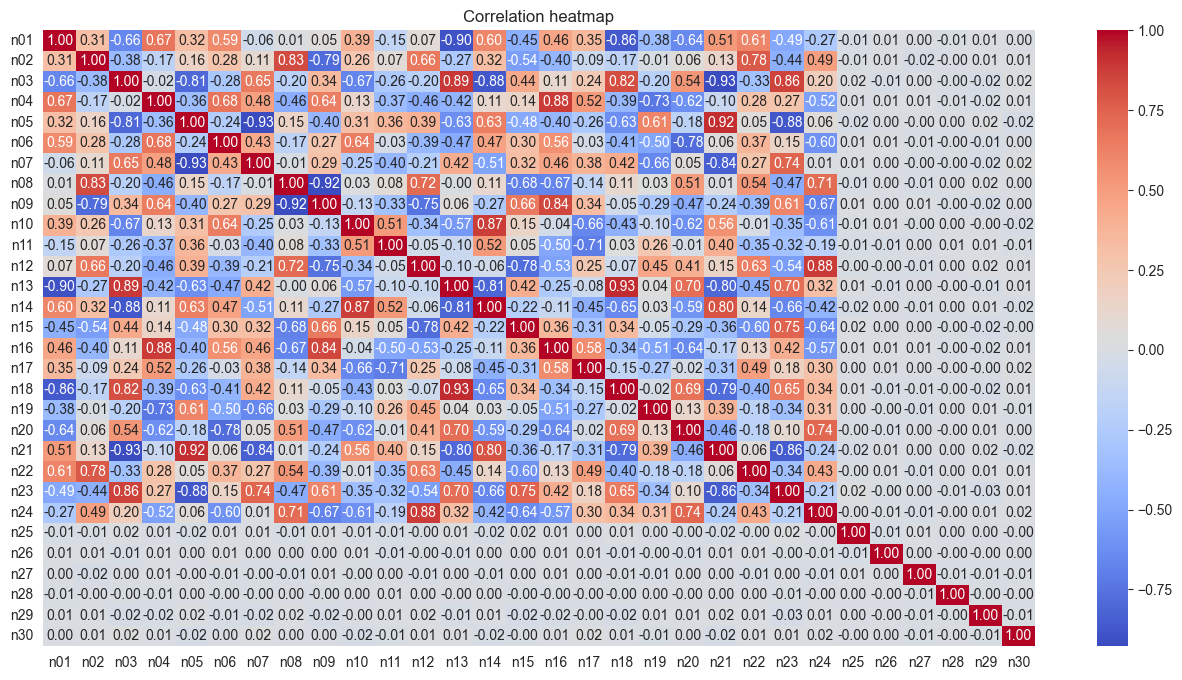

In [57]:
num_cols = X3.select_dtypes(include=['int64', 'float64'])

corr = num_cols.corr()
plt.figure(figsize=(16, 8))
sns.heatmap(
    corr,
    annot=True, 
    cmap='coolwarm',
    fmt='.2f',
)
plt.title('Correlation heatmap')
plt.show()
plt.savefig(DIRS_FOR_DATASETS[2] + "/correlation.png")
plt.close()

На heatmap мы видим, что признаки с n25 до n30 не имеют корреляции по модулю больше или равно 0.01, скорей всего это шум и он искажает признаковое пространство, если мы откинем эти признаки, то качество данных скорей всего увеличится и наши модели будут лучше себя вести и давать лучший результат (особенно KMeans)

In [58]:
X3 = X3.drop(columns=['n25', 'n26', 'n27', 'n28', 'n29', 'n30'])

In [59]:
X3.cat_a.value_counts()

cat_a
E    1692
A    1690
F    1666
D    1658
B    1655
C    1639
Name: count, dtype: int64

In [60]:
X3.cat_b.value_counts()

cat_b
V    1682
X    1681
Z    1675
W    1668
Y    1660
U    1634
Name: count, dtype: int64

Так как балансировка категориальных признаков примерно равна, то мы оставим оба категориальных признака, сделав OneHotEncoder + самих значений признака не так много, поэтому признаковое пространство не так сильно увеличиться

In [61]:
num_features = X3.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = ['cat_a', 'cat_b']

preprocess_3 = ColumnTransformer(
    transformers=[
        ('num', Pipeline(
            [
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]
        ), num_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features),
    ]
)

In [62]:
X3_prepared = preprocess_3.fit_transform(X3)

In [63]:
X3.shape

(10000, 26)

In [64]:
X3_prepared.shape

(10000, 36)

In [65]:
results = []

for k in k_vals:
    kmeans = KMeans(
        n_init=10,
        random_state=RANDOM_STATE,
        n_clusters=k
    )
    
    labels_km = kmeans.fit_predict(X3_prepared)
    results.append(
        (k, silhouette_score(X3_prepared, labels_km), davies_bouldin_score(X3_prepared, labels_km), calinski_harabasz_score(X3_prepared, labels_km))
    )

In [66]:
results = pd.DataFrame(results, columns=['clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz'])
results.sort_values('silhouette', ascending=False)

,clusters,silhouette,davies_bouldin,calinski_harabasz
4,6,0.640132,0.539880,17797.802628
3,5,0.628253,0.647561,11969.821177
5,7,0.582679,0.955821,15583.713760
2,4,0.519545,0.889907,6638.002168
6,8,0.510271,1.282439,13980.297584
7,9,0.418022,1.629254,12539.593538
1,3,0.403695,1.208980,4908.509564
8,10,0.348648,1.799652,11366.539392
0,2,0.334157,1.402725,4160.392065
11,13,0.329824,1.984394,8968.739272


In [67]:
kmeans = KMeans(
    n_clusters=6,
    n_init=10,
    random_state=RANDOM_STATE,
)
labels_km = kmeans.fit_predict(X3_prepared)

silhouette = silhouette_score(X3_prepared, labels_km)
davies_bouldin = davies_bouldin_score(X3_prepared, labels_km)
calinski_harabasz = calinski_harabasz_score(X3_prepared, labels_km)

metrics_summary['dataset-04'].update({'KMeans': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz}})

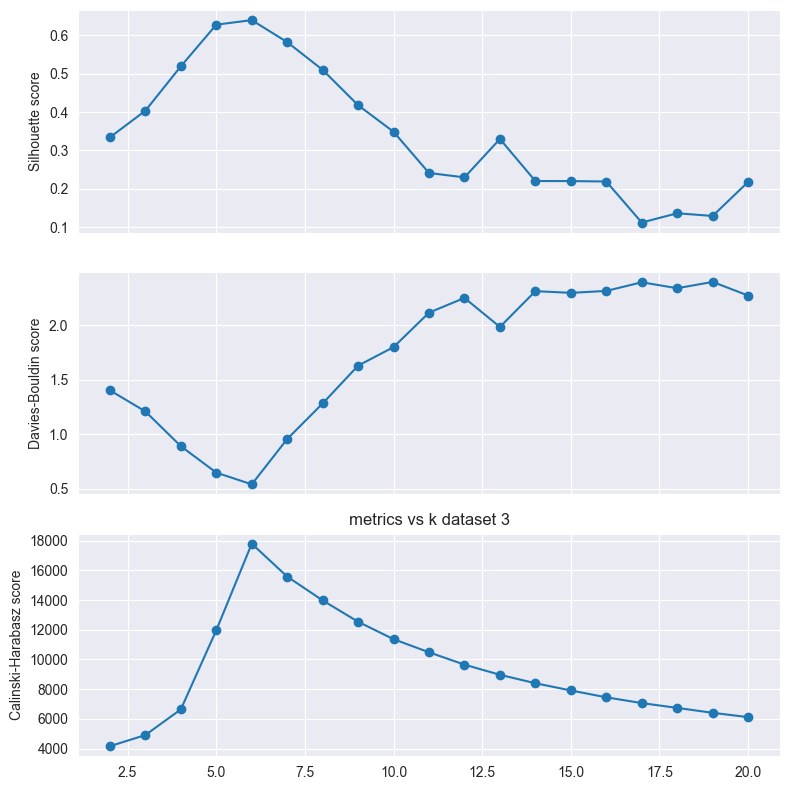

In [68]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(k_vals, results.silhouette, marker='o')
axes[0].set_ylabel('Silhouette score')
axes[0].grid(True)

axes[1].plot(k_vals, results.davies_bouldin, marker='o')
axes[1].set_ylabel('Davies-Bouldin score')
axes[1].grid(True)

axes[2].plot(k_vals, results.calinski_harabasz, marker='o')
axes[2].set_ylabel('Calinski-Harabasz score')
axes[2].grid(True)

plt.title("metrics vs k dataset 3")
plt.tight_layout()
plt.savefig(DIRS_FOR_DATASETS[2] + "/metrics_vs_k.png")
plt.show()
plt.close()

Отчетливо видим, что k = 6 лучший вариант для алгоритма KMeans

In [69]:
eps_values = np.arange(0.1, 3.1, 0.1)
min_samples_values = [3, 5, 10]

results = []

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels_db = dbscan.fit_predict(X3_prepared)
        
        noise_share = np.mean(labels_db == -1)
        mask = labels_db != -1
        
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        
        if n_clusters >= 2 and mask.sum() > 1:
            sil = silhouette_score(X3_prepared[mask], labels_db[mask])
            db = davies_bouldin_score(X3_prepared[mask], labels_db[mask])
            ch = calinski_harabasz_score(X3_prepared[mask], labels_db[mask])
        else:
            sil, db, ch = np.nan, np.nan, np.nan
        
        results.append(
            (
                eps,
                ms,
                n_clusters,
                sil,
                db,
                ch
            )
        )

In [70]:
res_df = pd.DataFrame(
    results,
    columns=['eps', 'ms', 'n_clusters', 'silhouette', 'davies_bouldin', 'calinski_harabasz']
)
res_df.sort_values('silhouette', ascending=False).head(10)

,eps,ms,n_clusters,silhouette,davies_bouldin,calinski_harabasz
14,0.5,10,2,0.910944,0.127081,64994.605147
62,2.1,10,6,0.641220,0.538210,17889.948765
61,2.1,5,6,0.641138,0.538338,17883.722631
60,2.1,3,6,0.641103,0.538368,17880.323059
65,2.2,10,6,0.640861,0.538701,17863.789609
63,2.2,3,6,0.640818,0.538775,17861.206590
64,2.2,5,6,0.640818,0.538775,17861.206590
68,2.3,10,6,0.640810,0.538847,17858.518290
66,2.3,3,6,0.640766,0.538921,17855.939341
67,2.3,5,6,0.640766,0.538921,17855.939341


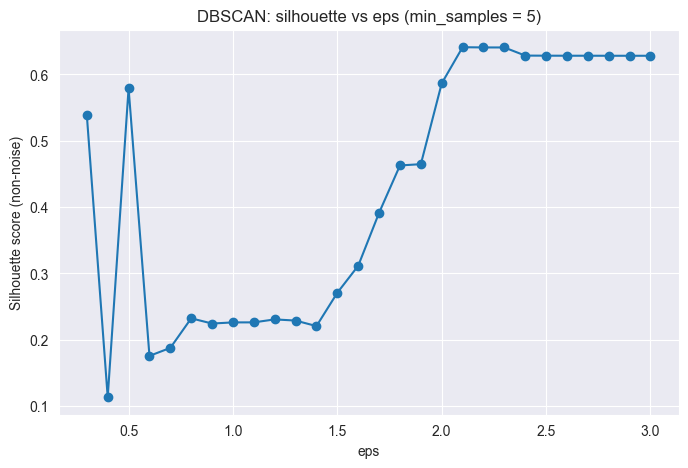

In [71]:
tmp = res_df[res_df['ms'] == 5]

plt.figure(figsize=(8, 5))
plt.plot(tmp['eps'], tmp['silhouette'], marker='o')
plt.xlabel('eps')
plt.ylabel('Silhouette score (non-noise)')
plt.title('DBSCAN: silhouette vs eps (min_samples = 5)')
plt.grid(True)
plt.show()
plt.savefig(DIRS_FOR_DATASETS[2] + '/silhouette_vs_eps')
plt.close()

In [72]:
dbscan = DBSCAN(
    eps=2.1,
    min_samples=10,
)
labels_db = dbscan.fit_predict(X3_prepared)

silhouette = silhouette_score(X3_prepared, labels_db)
davies_bouldin = davies_bouldin_score(X3_prepared, labels_db)
calinski_harabasz = calinski_harabasz_score(X3_prepared, labels_db)

metrics_summary['dataset-04'].update({'DBScan': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz, "noise_share": np.mean(labels_db == -1)}})

In [73]:
linkages = ['ward', 'average']

results = []

for linkage in linkages:
    for k in k_vals:
        agg = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )
        
        labels_agg = agg.fit_predict(X3_prepared)
        
        sil = silhouette_score(X3_prepared, labels_agg)
        db  = davies_bouldin_score(X3_prepared, labels_agg)
        ch  = calinski_harabasz_score(X3_prepared, labels_agg)
        
        results.append((linkage, k, sil, db, ch))


In [74]:
agg_df = pd.DataFrame(
    results,
    columns=['linkage', 'k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']
)

agg_df.sort_values('silhouette', ascending=False).head(10)

,linkage,k,silhouette,davies_bouldin,calinski_harabasz
4,ward,6,0.640132,0.539880,17797.802628
23,average,6,0.640132,0.539880,17797.802628
22,average,5,0.628253,0.647561,11969.821177
3,ward,5,0.628253,0.647561,11969.821177
24,average,7,0.620255,0.527793,14840.990186
25,average,8,0.610176,0.527991,12726.522693
26,average,9,0.603267,0.683916,11146.750548
5,ward,7,0.576043,0.990687,15344.919016
27,average,10,0.567603,0.649922,9912.975688
28,average,11,0.563721,0.640766,8925.289575


In [75]:
aggClust = AgglomerativeClustering(
    n_clusters=6,
    linkage='ward',
)
labels_agg = aggClust.fit_predict(X3_prepared)

silhouette = silhouette_score(X3_prepared, labels_agg)
davies_bouldin = davies_bouldin_score(X3_prepared, labels_agg)
calinski_harabasz = calinski_harabasz_score(X3_prepared, labels_agg)

metrics_summary['dataset-04'].update({'AgglomerativeClustering': {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz}})

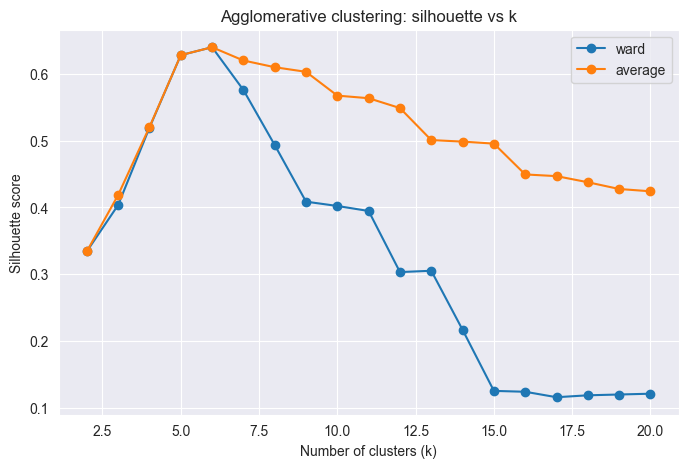

In [76]:
plt.figure(figsize=(8, 5))

for linkage in linkages:
    tmp = agg_df[agg_df['linkage'] == linkage]
    plt.plot(tmp['k'], tmp['silhouette'], marker='o', label=linkage)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Agglomerative clustering: silhouette vs k')
plt.legend()
plt.grid(True)
plt.show()
plt.close()

In [77]:
best_model = DBSCAN(eps=2.1, min_samples=10)
labels = best_model.fit_predict(X3_prepared)

save_csv_labels(DIR_FOR_ARTIFACTS + "labels_hw07_ds4.csv", sample_id_3, labels)
best_configs['dataset-04'] = {'eps':2.1, 'min_samples':10, 'n_clusters': 6}

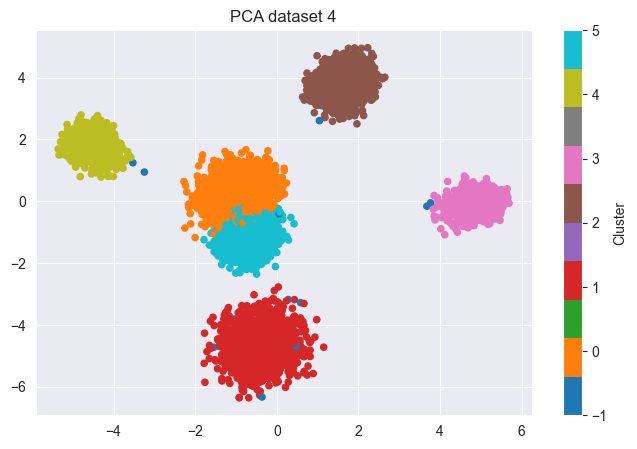

In [78]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X3_pca = pca.fit_transform(X3_prepared)

plt.figure(figsize=(8, 5))
plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=labels, s=20, cmap='tab10')

plt.colorbar(label='Cluster')
plt.title('PCA dataset 4')
plt.savefig(DIRS_FOR_DATASETS[2] + '/PCA.png')
plt.show()
plt.close()

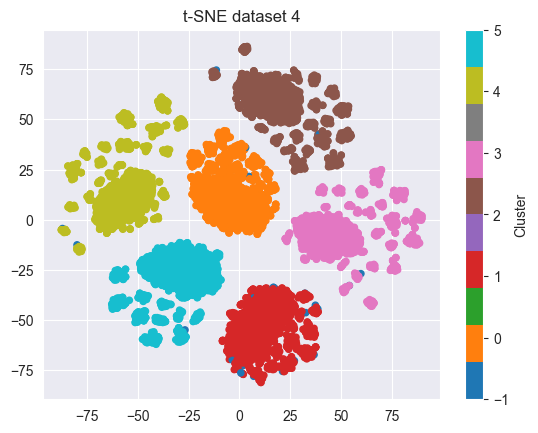

In [79]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X3_tsne = tsne.fit_transform(X3_prepared)

plt.scatter(
    X3_tsne[:, 0],
    X3_tsne[:, 1],
    c=labels,
    s=20,
    cmap='tab10',
)

plt.title('t-SNE dataset 4')
plt.colorbar(label='Cluster')
plt.savefig(DIRS_FOR_DATASETS[2] + '/t-SNE.png')
plt.show()
plt.close()

В 4 датасете были и числовые и категориальные признаки, на моменте EDA мы выявили числовые признаки, которые скорей всего являются шумом (мы от них избавились, помимо sample_id, n25, n26, n27, n28, n29, n30)

Также мы закодировали методом OneHot категориальные признаки, так как их распределение было довольно равным и самих значений признаков было не очень много.

После этого мы взяли 3 модели (KMeans, DBScan и AgglomerativeClustering)

Все три алгоритма выдали, что объекты делятся на 6 кластеров с примерно схожим silhouette, но лучшее значение показало DBScan (0.641220)

У DBScan был случай, когда он поделил на 2 кластера, но мы отбросили, так как слишком огромный разрыв в silhouette и DBScan просто занес в шум огромное кол-во объектов, из-за чего и получил такие показатели высокие и всего 2 кластера 

График PCA демонстрирует примерное распределение на 6 кластеров, хоть и имеется 2 очень близких друг к другу "Облачка" объектов, но скорей всего это из-за того, что множество признаков вносят свой вклад в пространство и PCA теряет частично информацию о них при сжатие признакового пространства 

In [82]:
save_json(DIR_FOR_ARTIFACTS + 'best_configs.json', best_configs)
save_json(DIR_FOR_ARTIFACTS + 'metrics_summary.json', metrics_summary)